### Homework 8 Using Cell DNA Data on SVM RBF / ROC Curve Plot

In [ ]:
# Import data and library

import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

# LOAD DATA
df = pd.read_csv("ML_HW_Data_CellDNA.csv", header=None)

In [ ]:
# Q1: Experiment your SVM RBF model with different “box constraints” and “kernel scales / gamma”. 

# 1st step is to separate Features (X) and Target (y)
X = df.iloc[:, :-1].values
y_raw = df.iloc[:, -1].values

# 2nd step is to convert to binary (0 or 1)
# any value not equal to 0 becomes 1
y = np.where(y_raw != 0, 1, 0)

# 3rd step I will complete feature scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 4th step I will define the hyperparameter experiment grid
# test low to high values to observe the transition from underfitting to overfitting

C_values = [0.1, 1, 10, 100]
gamma_values = [0.01, 0.1, 1, 10]

# hold all trained models (should help for Q2 and Q5)
experiment_models = {}

# 5th step is to complete the Grid Search
for c in C_values:
    for g in gamma_values:
        # SVM with RBF kernel
        clf = SVC(kernel='rbf', C=c, gamma=g, random_state=42)
        
        clf.fit(X_scaled, y)
        
        # store model 
        model_name = f"C={c}_Gamma={g}"
        experiment_models[model_name] = clf
        
        print(f"Trained Model: {model_name}")



Trained Model: C=0.1_Gamma=0.01
Trained Model: C=0.1_Gamma=0.1
Trained Model: C=0.1_Gamma=1
Trained Model: C=0.1_Gamma=10
Trained Model: C=1_Gamma=0.01
Trained Model: C=1_Gamma=0.1
Trained Model: C=1_Gamma=1
Trained Model: C=1_Gamma=10
Trained Model: C=10_Gamma=0.01
Trained Model: C=10_Gamma=0.1
Trained Model: C=10_Gamma=1
Trained Model: C=10_Gamma=10
Trained Model: C=100_Gamma=0.01
Trained Model: C=100_Gamma=0.1
Trained Model: C=100_Gamma=1
Trained Model: C=100_Gamma=10


In [4]:
# 2. what is the accuracy, Precision, Recall, and F-score for each class prediction under each of your above experiments? 

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# hold the metrics for Q2
q2_results = []

for name, model in experiment_models.items():
    y_pred = model.predict(X_scaled)
    
    # 1. overall Accuracy
    acc = accuracy_score(y, y_pred)
    
    # 2. metrics for Class 0 (Negative/Not Interesting)
    p0 = precision_score(y, y_pred, pos_label=0, zero_division=0)
    r0 = recall_score(y, y_pred, pos_label=0, zero_division=0)
    f0 = f1_score(y, y_pred, pos_label=0, zero_division=0)
    
    # 3. Metrics for Class 1 (Positive/Interesting)
    p1 = precision_score(y, y_pred, pos_label=1, zero_division=0)
    r1 = recall_score(y, y_pred, pos_label=1, zero_division=0)
    f1 = f1_score(y, y_pred, pos_label=1, zero_division=0)
    
    q2_results.append({
        'Model (C_Gamma)': name,
        'Accuracy': round(acc, 4),
        'C0_Precision': round(p0, 4),
        'C0_Recall': round(r0, 4),
        'C0_F1': round(f0, 4),
        'C1_Precision': round(p1, 4),
        'C1_Recall': round(r1, 4),
        'C1_F1': round(f1, 4)
    })

# Convert to a DF for visualization
df_q2 = pd.DataFrame(q2_results)
print(df_q2.to_string(index=False))

 Model (C_Gamma)  Accuracy  C0_Precision  C0_Recall  C0_F1  C1_Precision  C1_Recall  C1_F1
C=0.1_Gamma=0.01    0.8357        0.8357     1.0000 0.9105        0.0000      0.000 0.0000
 C=0.1_Gamma=0.1    0.9030        0.9105     0.9803 0.9441        0.8361      0.510 0.6335
   C=0.1_Gamma=1    0.8357        0.8357     1.0000 0.9105        0.0000      0.000 0.0000
  C=0.1_Gamma=10    0.8357        0.8357     1.0000 0.9105        0.0000      0.000 0.0000
  C=1_Gamma=0.01    0.9096        0.9242     0.9715 0.9473        0.8041      0.595 0.6839
   C=1_Gamma=0.1    0.9318        0.9473     0.9725 0.9597        0.8382      0.725 0.7775
     C=1_Gamma=1    0.9737        0.9731     0.9961 0.9845        0.9773      0.860 0.9149
    C=1_Gamma=10    1.0000        1.0000     1.0000 1.0000        1.0000      1.000 1.0000
 C=10_Gamma=0.01    0.9236        0.9417     0.9685 0.9549        0.8129      0.695 0.7493
  C=10_Gamma=0.1    0.9523        0.9651     0.9784 0.9717        0.8817      0.820 0.8497

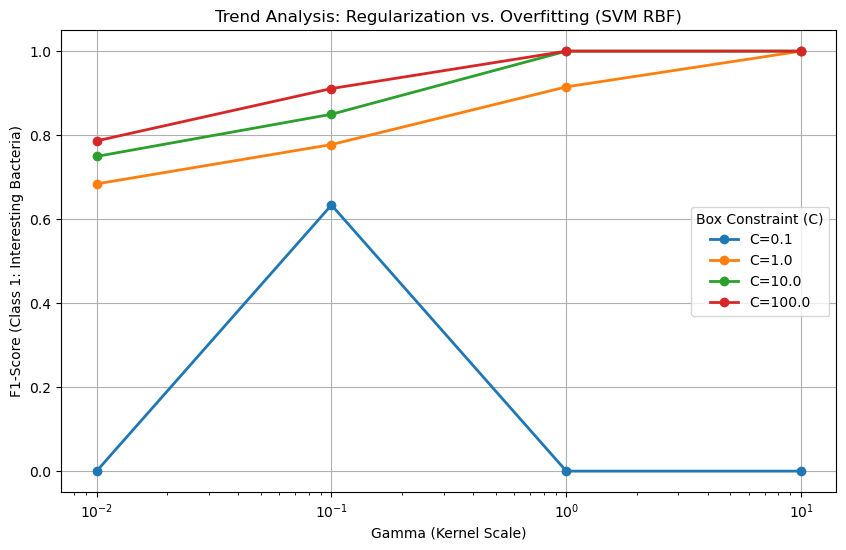

In [ ]:
import matplotlib.pyplot as plt

# extract the numerical C and Gamma values from Q2 DataFrame to plot them
df_q2[['C', 'Gamma']] = df_q2['Model (C_Gamma)'].str.extract(r'C=(.*)_Gamma=(.*)').astype(float)

plt.figure(figsize=(10, 6))

# Plot a line for each Box Constraint (C)
for c_val in df_q2['C'].unique():
    subset = df_q2[df_q2['C'] == c_val]
    plt.plot(subset['Gamma'], subset['C1_F1'], marker='o', lw=2, label=f'C={c_val}')

# gamma values scale by 10x (0.01 to 10)
plt.xscale('log') 
plt.xlabel('Gamma (Kernel Scale)')
plt.ylabel('F1-Score (Class 1: Interesting Bacteria)')
plt.title('Trend Analysis: Regularization vs. Overfitting (SVM RBF)')
plt.legend(title='Box Constraint (C)')
plt.grid(True)

# Save the plot
plt.savefig("Trend_Plot_Q4.png")
plt.show()

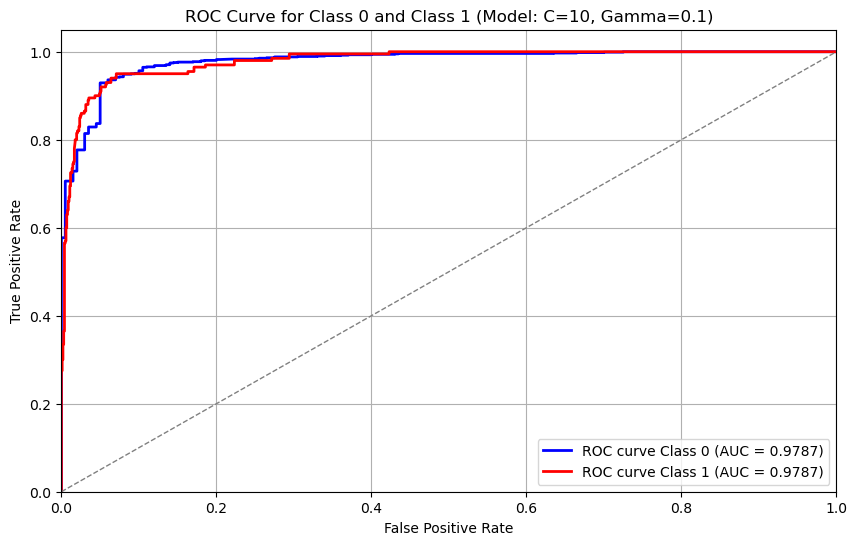

In [7]:
# Q4: Optional: plotting a graph with clear legends and tick labels to illustrate the trend will be very helpful. 
# Q5.	Create an ROC curve plot for  **EACH**  class in Just ONE of your experiments. 


import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

# Q5: use the model C=10, Gamma=0.1 
# IMPORTANT: recreate the model with probability=True to get ROC curves
clf_roc = SVC(kernel='rbf', C=10, gamma=0.1, probability=True, random_state=42)
clf_roc.fit(X_scaled, y)

# probabilities of each class
y_prob = clf_roc.predict_proba(X_scaled)

# calc ROC for Class 0
# For Class 0, treat '0' as the positive outcome, so invert y (1-y)
fpr0, tpr0, _ = roc_curve(1-y, y_prob[:, 0])
roc_auc0 = auc(fpr0, tpr0)

# calc ROC for Class 1
fpr1, tpr1, _ = roc_curve(y, y_prob[:, 1])
roc_auc1 = auc(fpr1, tpr1)

# Plotting
plt.figure(figsize=(10, 6))
plt.plot(fpr0, tpr0, color='blue', lw=2, label=f'ROC curve Class 0 (AUC = {roc_auc0:.4f})')
plt.plot(fpr1, tpr1, color='red', lw=2, label=f'ROC curve Class 1 (AUC = {roc_auc1:.4f})')

# diagonal line represents random guessing
plt.plot([0, 1], [0, 1], color='gray', lw=1, linestyle='--')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for Class 0 and Class 1 (Model: C=10, Gamma=0.1)')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()